<a href="https://colab.research.google.com/github/ahmed-zunaira/APS360_Project/blob/main/notebooks/APS360_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APS360 Project: Anomaly Detection of Phytoplankton


## 1. Install & Clone Github

Link to Google Drive with data: https://drive.google.com/drive/folders/1hotNZLICxkAaICcdnxRUh9XPlTkgY8m5?usp=sharing

In [ ]:
!git clone https://github.com/ahmed-zunaira/APS360_Project.git

Cloning into 'APS360_Project'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 78 (delta 36), reused 40 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 43.18 MiB | 17.68 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [ ]:
!pip install earthaccess xarray netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 90.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is i

In [ ]:
%cd /content/APS360_Project/src

/content/APS360_Project/src


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os

from autoencoder import Autoencoder
from data_loader import Dataload

## 2. Analysis


In [ ]:
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
# plots the training curve of model
def plot (batch_size=32, learning_rate=0.001, epochs=30):
    train_loss = np.loadtxt("/content/APS360_Project/src/CAE_bs{}_lr{}_epoch{}_train_loss.csv".format(batch_size,learning_rate,epochs))
    val_loss = np.loadtxt("/content/APS360_Project/src/CAE_bs{}_lr{}_epoch{}_val_loss.csv".format(batch_size,learning_rate,epochs))

    plt.title ("Train vs. Validation Loss")
    plt.plot(range(1, len(train_loss)+1), train_loss, label="Train")
    plt.plot(range(1, len(val_loss)+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend(loc='best')
    plt.show()

In [ ]:
!python train.py

Epoch 1: Train Loss: 0.03989164259595176, Validation Loss: 0.020254763929794233
Epoch 2: Train Loss: 0.018620838954423864, Validation Loss: 0.014247641588250795
Epoch 3: Train Loss: 0.012170580642608305, Validation Loss: 0.009530038728068272
Epoch 4: Train Loss: 0.009981037195151051, Validation Loss: 0.008775482031827172
Epoch 5: Train Loss: 0.009297912125475705, Validation Loss: 0.008053487244372567
Epoch 6: Train Loss: 0.00861014419933781, Validation Loss: 0.0075933625145504875
Epoch 7: Train Loss: 0.008149359025992453, Validation Loss: 0.007301662350073457
Epoch 8: Train Loss: 0.007960291889806589, Validation Loss: 0.0070633976720273495
Epoch 9: Train Loss: 0.008014431688934565, Validation Loss: 0.006918241425106923
Epoch 10: Train Loss: 0.007559461955679581, Validation Loss: 0.006815588256965081
Epoch 11: Train Loss: 0.007380601193290204, Validation Loss: 0.006694012243921558
Epoch 12: Train Loss: 0.007261336179605375, Validation Loss: 0.00660478905774653
Epoch 13: Train Loss: 0.00

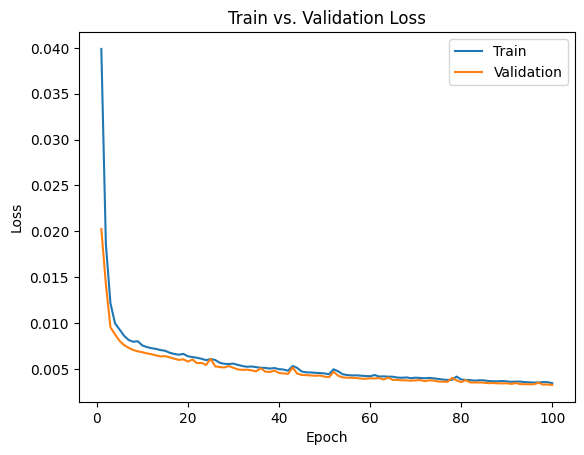

In [ ]:
plot(16, 0.001, 100)

In [ ]:
def setup_inference (model_path, dataloader):
    model = Autoencoder()

    # load model weights
    model.load_state_dict(torch.load(model_path, weights_only=True))

    model.eval() # set model to eval mode

    data_iter = iter(dataloader) # get first batch of images

    imgs, _ = next(data_iter)

    return model, imgs # return model and one batch of images

def calculate_difference_map (model, images):
    with torch.no_grad():
        recons = model(images) # get model's reconstructions

        diff_map = torch.abs(images - recons) # calculate differene between reconstructions and images

        return recons, diff_map

# shows original image, model's reconstruction, and difference map between them
def plot_triplets(images, reconstructions, difference_maps, num_to_plot=3):
    fig, axes = plt.subplots(nrows=num_to_plot, ncols=3, figsize=(12, 4 * num_to_plot))

    for i in range(num_to_plot):
        image = images[i]
        recon = reconstructions[i]
        diff_map = difference_maps[i]

        image_np = image.detach().numpy()
        recon_np = recon.detach().numpy()
        diff_map_np = diff_map.detach().numpy()

        # remove channel dimension
        image_np = image_np.squeeze(0)
        recon_np = recon_np.squeeze(0)
        diff_map_np = diff_map_np.squeeze(0)

        axes[i, 0].imshow(image_np, cmap='viridis', vmin=0.0, vmax=3.0)
        axes[i, 0].axis('off')
        axes[i, 0].set_title("Original")

        axes[i, 1].imshow(recon_np, cmap='viridis', vmin=0.0, vmax=3.0)
        axes[i, 1].axis('off')
        axes[i, 1].set_title("Reconstruction")

        axes[i, 2].imshow(diff_map_np, cmap='hot', vmin=0.0, vmax=1.0)
        axes[i, 2].axis('off')
        axes[i, 2].set_title("Difference")
    plt.tight_layout()
    plt.show()

# function for just using the processed directory for data rather than passing a dataloader
def setup_eval_environment(model_path, processed_dir):
    model = Autoencoder()

    # load model weights
    model.load_state_dict(torch.load(model_path, weights_only=True))

    model.eval() # set model to eval mode

    dataset = Dataload(processed_dir)

    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)

    return model, dataloader

# calculates losses from model
def calculate_all_losses(model, dataloader):
    criterion = nn.MSELoss()

    model.eval()

    all_losses = []

    # get MSE loss for each image and reconstruction from model
    with torch.no_grad():
        for data in dataloader:
            imgs, _ = data
            recons = model(imgs)

            loss = criterion (imgs, recons)
            all_losses.append(loss.item())

    return all_losses

# calculates threshold of losses with given percentile
def find_threshold(losses_list, percentile=95):
    losses_np = np.array(losses_list)

    threshold = np.percentile(losses_np, 95)

    return threshold

# calculates moving average of data with provided window size
def moving_average(data, window_size=4):
  return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

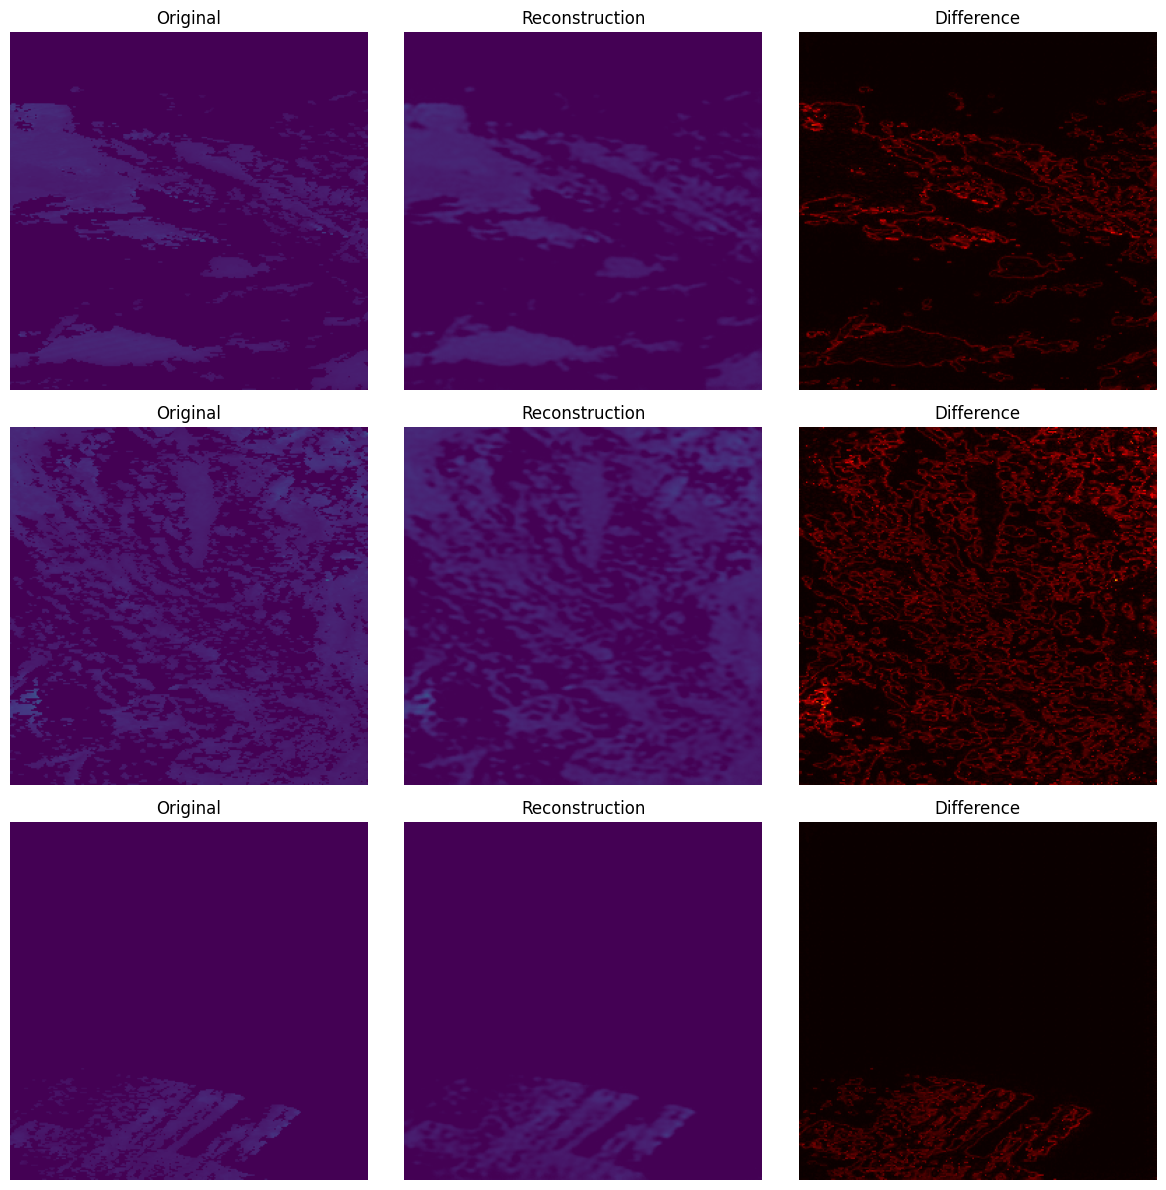

In [ ]:
# plotting results of model on normal data

processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed"
model_weights_file = "/content/APS360_Project/src/CAE_model.pth"

if not os.path.exists(processed_dir):
  print ("Directory not found")
  exit()

dataset = Dataload(processed_dir)

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

model, imgs = setup_inference(model_weights_file, dataloader)

recons, diff_maps = calculate_difference_map(model, imgs)

plot_triplets(imgs, recons, diff_maps, 3)

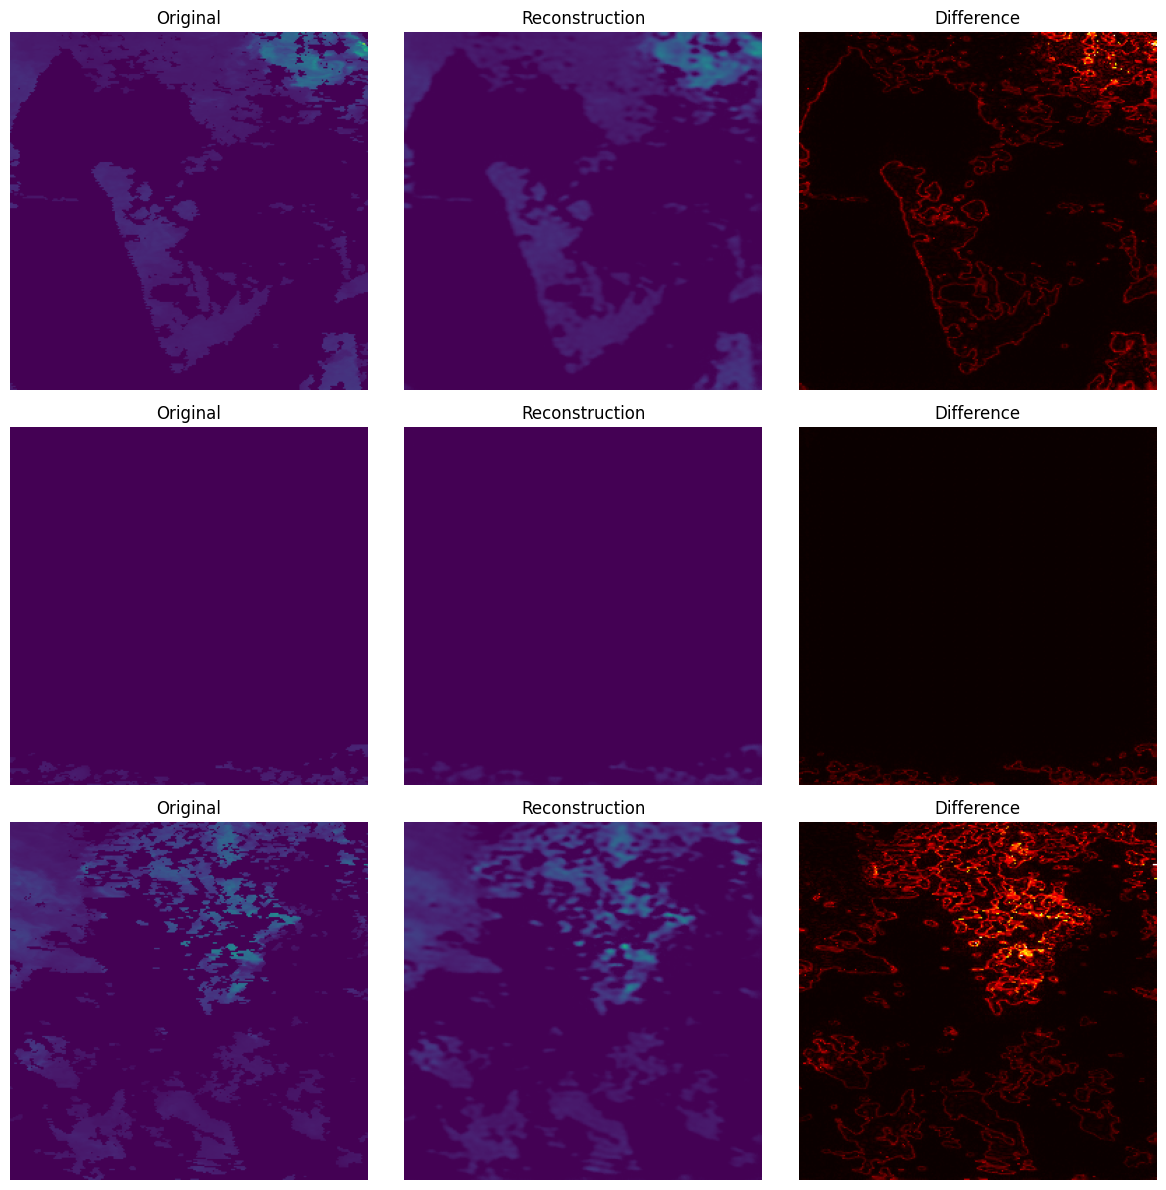

In [ ]:
# plotting results of model on anomaly data

processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_2008_data"
model_weights_file = "/content/APS360_Project/src/CAE_model.pth"

if not os.path.exists(processed_dir):
  print ("Directory not found")
  exit()

dataset = Dataload(processed_dir)

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

model, imgs = setup_inference(model_weights_file, dataloader)

recons, diff_maps = calculate_difference_map(model, imgs)

plot_triplets(imgs, recons, diff_maps, 3)

In [ ]:
print ("Testing Data:", len(dataset))

Testing Data: 46


In [ ]:
processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed"
model_weights_file = "/content/APS360_Project/src/CAE_model.pth"

model, dataloader = setup_eval_environment(model_weights_file, processed_dir)

losses = calculate_all_losses(model, dataloader)

threshold = find_threshold(losses)

print ("Calculated threshold for model:", threshold)

Calculated threshold for model: 0.008788041584193697


In [ ]:
processed_anomaly_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_2008_data"

model, dataloader = setup_eval_environment(model_weights_file, processed_anomaly_dir)

anomaly_losses = calculate_all_losses(model, dataloader)

In [ ]:
normal_losses_smoothed = moving_average(np.array(losses))
anomaly_losses_smoothed = moving_average(np.array(anomaly_losses))

In [ ]:
# import for baseline model

import glob
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

In [ ]:
def load_flattened_data(path):
  files = glob.glob(f"{path}/*.pt")
  data = []
  for curr_file in files:
    img = torch.load(curr_file, weights_only=False).numpy().flatten()
    data.append(img)
  return np.array(data)

In [ ]:
# perform PCA analysis

processed_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed"
processed_anomaly_dir = "/content/drive/MyDrive/Phytoplankton_Project/data/processed_2008_data"

train_data = load_flattened_data(processed_dir)
test_data = load_flattened_data(processed_anomaly_dir)

pca = PCA(n_components=0.95) # PCA uses as many components it needs to evaluate 95% of variance in data

pca.fit(train_data)

train_compressed = pca.transform(train_data)
train_reconstructed = pca.inverse_transform(train_compressed)

test_compressed = pca.transform(test_data)
test_reconstructed = pca.inverse_transform(test_compressed)

normal_loss = np.mean((train_data - train_reconstructed)**2, axis=1)
anomaly_loss = np.mean((test_data - test_reconstructed)**2, axis=1)
threshold = np.percentile(normal_loss, 95)

print ("Calculated threshold for PCA:", threshold)
print ("PCA's components:", pca.n_components_)

Calculated threshold for PCA: 0.004435284
PCA's components: 253


In [ ]:
# calculates z scores of provided loss data
def compute_z_scores (normal_data, anomaly_data):
  normal_baseline_mean = np.mean(normal_data)
  normal_baseline_std = np.std(normal_data)

  # preventing dividing by zero
  if normal_baseline_std == 0:
    normal_baseline_std = 1e-8

  z_normal = (normal_data - normal_baseline_mean) / normal_baseline_std
  z_anomaly = (anomaly_data - normal_baseline_mean) / normal_baseline_std

  return z_normal, z_anomaly

In [ ]:
# plots provided z scores and showcases threshold for each model
def plot_z_scores(ae_z_normal, ae_z_anomaly, pca_z_normal, pca_z_anomaly, ae_threshold, pca_threshold):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

  min_val_ae_normal = np.min(ae_z_normal)
  min_val_ae_anomaly = np.min(ae_z_anomaly)
  min_val_pca_normal = np.min(pca_z_normal)
  min_val_pca_anomaly = np.min(pca_z_anomaly)
  min_val = min(min_val_ae_normal, min_val_ae_anomaly, min_val_pca_normal, min_val_pca_anomaly)

  max_val_ae_normal = np.max(ae_z_normal)
  max_val_ae_anomaly = np.max(ae_z_anomaly)
  max_val_pca_normal = np.max(pca_z_normal)
  max_val_pca_anomaly = np.max(pca_z_anomaly)
  max_val = max(max_val_ae_normal, max_val_ae_anomaly, max_val_pca_normal, max_val_pca_anomaly)

  ax1.set_ylim(min_val - 0.5, max_val + 0.5) # adding buffers so it doesnt hit top/bottom
  ax2.set_ylim(min_val - 0.5, max_val + 0.5)

  x_ae_normal = range(len(ae_z_normal))
  x_ae_anomaly = range(len(ae_z_normal), len(ae_z_normal) + len(ae_z_anomaly))

  x_pca_normal = range(len(pca_z_normal))
  x_pca_anomaly = range(len(pca_z_normal), len(pca_z_normal) + len(pca_z_anomaly))

  ax1.plot(x_ae_normal, ae_z_normal, color='blue', alpha=0.7, linewidth=2, label='Normal Baseline (2016-2025)')
  ax1.plot(x_ae_anomaly, ae_z_anomaly, color='red', alpha=0.7, linewidth=2, label='2008 Coastal Bloom')
  ax1.axhline(y=ae_threshold, color='black', linestyle='--', label='95% Threshold')
  ax1.fill_between(x_ae_anomaly, ae_z_anomaly, ae_threshold, where=(ae_z_anomaly > ae_threshold), color='red', alpha=0.2, interpolate=True)
  ax1.set_ylabel("Z-Scores of Reconstruction Loss")

  ax1.set_title("Convolutional Autoencoder")
  ax1.legend()

  ax2.plot(x_pca_normal, pca_z_normal, color='blue', alpha=0.7, linewidth=2, label='Normal Baseline (2016-2025)')
  ax2.plot(x_pca_anomaly, pca_z_anomaly, color='red', alpha=0.7, linewidth=2, label='2008 Coastal Bloom')
  ax2.axhline(y=pca_threshold, color='black', linestyle='--', label='95% Threshold')
  ax2.fill_between(x_pca_anomaly, pca_z_anomaly, pca_threshold, where=(pca_z_anomaly > pca_threshold), color='red', alpha=0.2, interpolate=True)
  ax1.set_ylabel("Z-Scores of Reconstruction Loss")

  ax2.set_title("PCA Baseline")
  ax2.legend()

  start_idx = 0
  split_idx = len(ae_z_normal)
  end_idx = split_idx + len(ae_z_anomaly)

  ax1.set_xticks([start_idx, split_idx, end_idx])
  ax1.set_xticklabels(['2016\n(Baseline Start)', '2026\n(Baseline End)', '2008\n\nAnomaly Test'])

  ax2.set_xticks([start_idx, split_idx, end_idx])
  ax2.set_xticklabels(['2016\n(Baseline Start)', '2026\n(Baseline End)', '2008\n\nAnomaly Test'])

  plt.tight_layout()
  plt.show()


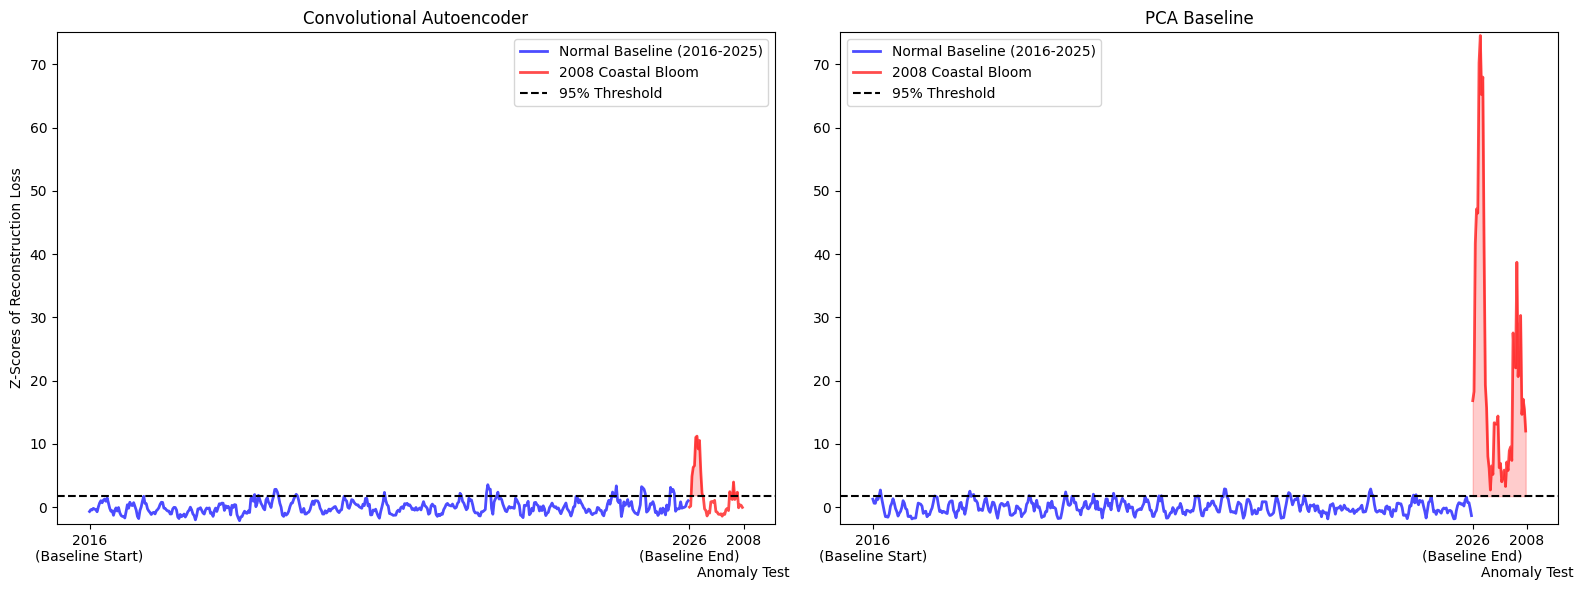

In [ ]:
# smoothing pca losses data using moving average
pca_normal_losses_smooth = moving_average(normal_loss)
pca_anomaly_losses_smooth = moving_average(anomaly_loss)

# computing z-scores of smoothed losses data for both models and data types
ae_z_normal, ae_z_anomaly = compute_z_scores(normal_losses_smoothed, anomaly_losses_smoothed)
pca_z_normal, pca_z_anomaly = compute_z_scores(pca_normal_losses_smooth, pca_anomaly_losses_smooth)

# calculating the z-score 95th percentile threshold
ae_threshold = np.percentile(ae_z_normal, 95)
pca_threshold = np.percentile(pca_z_normal, 95)

# plotting the z scores for each model
plot_z_scores(ae_z_normal, ae_z_anomaly, pca_z_normal, pca_z_anomaly, ae_threshold, pca_threshold)

In [ ]:
print ("CAE threshold:", ae_threshold)
print ("PCA's threshold:", pca_threshold)

CAE threshold: 1.8007762912219853
PCA's threshold: 1.75992482002375
